In [1]:
# ============================================================
# CELL 1: Setup and imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, chi2_contingency
from dataclasses import dataclass
from typing import List, Optional, Dict
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

print("✅ Setup complete. NumPy:", np.__version__, "| Pandas:", pd.__version__)

✅ Setup complete. NumPy: 2.1.3 | Pandas: 2.2.3


In [2]:
# ============================================================
# CELL 2: Synthetic healthcare lab data generator
# ============================================================
def generate_healthcare_data(n_patients=250, n_days=30, drift_start_day=15, seed=42):
    """
    Generate longitudinal lab data for n_patients over n_days.
    One lab panel per patient per day.

    Drift injected from drift_start_day onward:
      • New assay lot (glucose +8 mg/dL)
      • Population shift (older patients)
      • Seasonal creatinine increase
    Cholesterol and sex act as CONTROL features (should NOT drift).
    """
    rng = np.random.default_rng(seed)

    # Static patient characteristics
    patient_ids = [f"P{str(i).zfill(4)}" for i in range(1, n_patients + 1)]
    base_ages = rng.normal(55, 18, n_patients).clip(18, 95)
    patient_sex = rng.choice(["M", "F"], n_patients, p=[0.48, 0.52])
    patient_bmi = rng.normal(27, 5, n_patients).clip(15, 50)

    records = []
    for day in range(1, n_days + 1):
        in_drift = day >= drift_start_day

        # Age shift after drift
        if in_drift:
            day_ages = base_ages + rng.normal(5, 3, n_patients).clip(0, 15)
        else:
            day_ages = base_ages

        # Assay lot changes with drift
        assay_lot = rng.choice(
            ["LOT-A", "LOT-B"], n_patients,
            p=[0.9, 0.1] if not in_drift else [0.3, 0.7],
        )

        # Baseline lab values
        glucose     = rng.normal(95 + 0.3 * (day_ages - 55), 15, n_patients)
        cholesterol = rng.normal(190 + 0.5 * (day_ages - 55), 35, n_patients)
        hemoglobin  = rng.normal(14.5 - 0.05 * (day_ages - 55), 1.5, n_patients)
        creatinine  = np.exp(rng.normal(-0.3 + 0.01 * (day_ages - 55), 0.3, n_patients))

        # Inject drift
        if in_drift:
            glucose    += 8.0        # assay lot effect
            creatinine *= 1.15       # seasonal effect

        for i in range(n_patients):
            records.append({
                "day": day,
                "patient_id": patient_ids[i],
                "age": day_ages[i],
                "sex": patient_sex[i],
                "bmi": patient_bmi[i],
                "glucose_mgdl": glucose[i],
                "cholesterol_mgdl": cholesterol[i],
                "hemoglobin_gdl": hemoglobin[i],
                "creatinine_mgdl": creatinine[i],
                "assay_lot": assay_lot[i],
            })

    return pd.DataFrame(records)


print("Generating healthcare data...")
healthcare_df = generate_healthcare_data(n_patients=250, n_days=30, drift_start_day=15, seed=42)
print(f"  Total records:   {len(healthcare_df):,}")
print(f"  Unique patients: {healthcare_df['patient_id'].nunique()}")
print(f"  Days simulated:  {healthcare_df['day'].nunique()}")
print()
print(healthcare_df.head())

Generating healthcare data...
  Total records:   7,500
  Unique patients: 250
  Days simulated:  30

   day patient_id        age sex        bmi  glucose_mgdl  cholesterol_mgdl  \
0    1      P0001  60.484907   F  30.062430    106.125194        165.004050   
1    1      P0002  36.280286   M  30.327926     68.320049        181.570630   
2    1      P0003  68.508122   F  32.426435    104.018039        216.722857   
3    1      P0004  71.930165   M  28.832657     95.539753        220.101757   
4    1      P0005  19.881367   M  25.568756     77.222558        226.756488   

   hemoglobin_gdl  creatinine_mgdl assay_lot  
0       13.011525         1.029668     LOT-A  
1       16.753074         0.407507     LOT-A  
2       11.765089         0.801087     LOT-A  
3       14.146044         0.686174     LOT-A  
4       16.524043         0.539139     LOT-A  


In [3]:
# ============================================================
# CELL 3: Synthetic fraud transaction data generator
# ============================================================
def generate_fraud_data(n_accounts=300, n_days=30, drift_start_day=15, seed=42):
    """
    Generate daily transaction data for n_accounts over n_days.

    Drift injected from drift_start_day onward:
      • New fraud ring (country shift + higher velocity + larger amounts)
    account_age_days and hour_of_day act as CONTROL features.
    """
    rng = np.random.default_rng(seed)

    account_ids = [f"A{str(i).zfill(4)}" for i in range(1, n_accounts + 1)]
    home_country = rng.choice(
        ["US", "UK", "DE", "FR", "BR"], n_accounts, p=[0.6, 0.15, 0.1, 0.1, 0.05],
    )
    account_age_days = rng.integers(30, 2000, n_accounts)

    records = []
    for day in range(1, n_days + 1):
        in_drift = day >= drift_start_day
        for i in range(n_accounts):
            n_txn = rng.poisson(3 if not in_drift else 4.5)
            for _ in range(n_txn):
                if in_drift and rng.random() < 0.30:
                    # Fraud-ring behaviour
                    country  = rng.choice(
                        ["US", "UK", "DE", "FR", "BR"],
                        p=[0.30, 0.10, 0.10, 0.10, 0.40],
                    )
                    amount   = np.exp(rng.normal(4.5, 1.2))
                    category = rng.choice(
                        ["retail", "travel", "grocery", "online", "gas"],
                        p=[0.25, 0.20, 0.10, 0.35, 0.10],
                    )
                else:
                    country  = home_country[i]
                    amount   = np.exp(rng.normal(4.0, 1.5))
                    category = rng.choice(
                        ["retail", "travel", "grocery", "online", "gas"],
                        p=[0.40, 0.10, 0.20, 0.20, 0.10],
                    )

                records.append({
                    "day": day,
                    "account_id": account_ids[i],
                    "amount_usd": amount,
                    "hour_of_day": int(rng.integers(0, 24)),
                    "txn_count_24h": n_txn,
                    "merchant_category": category,
                    "country": country,
                    "account_age_days": account_age_days[i],
                    "is_fraud": int(in_drift and rng.random() < 0.05),
                })

    return pd.DataFrame(records)


print("Generating fraud data...")
fraud_df = generate_fraud_data(n_accounts=300, n_days=30, drift_start_day=15, seed=42)
print(f"  Total transactions: {len(fraud_df):,}")
print(f"  Unique accounts:    {fraud_df['account_id'].nunique()}")
print(f"  Days simulated:     {fraud_df['day'].nunique()}")
print()
print(fraud_df.head())

Generating fraud data...
  Total transactions: 34,439
  Unique accounts:    300
  Days simulated:     30

   day account_id   amount_usd  hour_of_day  txn_count_24h merchant_category  \
0    1      A0002    24.511678           14              3               gas   
1    1      A0002   103.734594           11              3           grocery   
2    1      A0002    89.388586            5              3            retail   
3    1      A0003    44.848660           22              5            travel   
4    1      A0003  1018.940703           23              5            retail   

  country  account_age_days  is_fraud  
0      US              1564         0  
1      US              1564         0  
2      US              1564         0  
3      FR              1485         0  
4      FR              1485         0  


In [4]:
# ============================================================
# CELL 4: DriftMonitor — reusable drift monitoring layer
# ============================================================
@dataclass
class DriftResult:
    feature: str
    test: str
    statistic: float
    p_value: float
    effect_size: float
    is_drift: bool


class DriftMonitor:
    """
    Domain-agnostic drift monitoring layer for tabular data.

    • KS test for numeric features, Chi-Squared for categorical.
    • Two-gate decision: BOTH p-value AND effect-size must breach.
      (avoids p-hacking on large samples)
    • Rolling history supports a retraining decision policy.
    """

    def __init__(
        self,
        reference_df: pd.DataFrame,
        numeric_features: List[str],
        categorical_features: List[str],
        p_threshold: float = 0.01,
        effect_size_threshold: float = 0.10,
        sample_size: int = 5000,
        name: str = "monitor",
    ):
        self.reference_df = reference_df
        self.numeric_features = numeric_features
        self.categorical_features = categorical_features
        self.p_threshold = p_threshold
        self.effect_size_threshold = effect_size_threshold
        self.sample_size = sample_size
        self.name = name
        self.history: List[Dict] = []

    def _sample(self, df: pd.DataFrame) -> pd.DataFrame:
        return df if len(df) <= self.sample_size else df.sample(self.sample_size, random_state=42)

    def _test_numeric(self, ref, cur, feature: str) -> DriftResult:
        stat, p = ks_2samp(ref, cur)
        return DriftResult(
            feature=feature, test="KS",
            statistic=float(stat), p_value=float(p),
            effect_size=float(stat),
            is_drift=bool(p < self.p_threshold and stat > self.effect_size_threshold),
        )

    def _test_categorical(self, ref, cur, feature: str) -> DriftResult:
        cats = sorted(set(ref.unique()) | set(cur.unique()))
        r = ref.value_counts().reindex(cats, fill_value=0).values
        c = cur.value_counts().reindex(cats, fill_value=0).values
        table = np.vstack([r, c])
        table = table[:, table.sum(axis=0) > 0]
        if table.shape[1] < 2:
            return DriftResult(feature, "Chi2", 0.0, 1.0, 0.0, False)
        chi2, p, _, _ = chi2_contingency(table)
        n = table.sum()
        cramers_v = float(np.sqrt(chi2 / (n * (min(table.shape) - 1))))
        return DriftResult(
            feature=feature, test="Chi2",
            statistic=float(chi2), p_value=float(p),
            effect_size=cramers_v,
            is_drift=bool(p < self.p_threshold and cramers_v > self.effect_size_threshold),
        )

    def check(self, current_df: pd.DataFrame, date: Optional[str] = None) -> Dict:
        cur = self._sample(current_df)
        results: List[DriftResult] = []

        for f in self.numeric_features:
            results.append(self._test_numeric(
                self.reference_df[f].dropna().values,
                cur[f].dropna().values, f,
            ))

        for f in self.categorical_features:
            results.append(self._test_categorical(
                self.reference_df[f].dropna(),
                cur[f].dropna(), f,
            ))

        drifted = [r for r in results if r.is_drift]
        summary = {
            "date": date,
            "n_samples": int(len(cur)),
            "n_features": len(results),
            "n_drifted": len(drifted),
            "drift_ratio": len(drifted) / len(results) if results else 0.0,
            "features": [
                {
                    "feature": r.feature,
                    "test": r.test,
                    "statistic": round(r.statistic, 6),
                    "p_value": round(r.p_value, 6),
                    "effect_size": round(r.effect_size, 4),
                    "is_drift": r.is_drift,
                } for r in results
            ],
        }
        self.history.append(summary)
        return summary

    def decision(self, recent_days: int = 3, drift_ratio_threshold: float = 0.3) -> str:
        recent = self.history[-recent_days:]
        if len(recent) < recent_days:
            return "INSUFFICIENT_HISTORY"
        if all(s["drift_ratio"] >= drift_ratio_threshold for s in recent):
            return "RETRAIN_RECOMMENDED"
        if any(s["drift_ratio"] > 0 for s in recent):
            return "MONITOR_CLOSELY"
        return "HEALTHY"


print("✅ DriftMonitor class ready.")

✅ DriftMonitor class ready.


In [5]:
# ============================================================
# CELL 5: Healthcare pipeline — daily drift monitoring
# ============================================================
print("=" * 78)
print("🏥  HEALTHCARE LAB RESULTS — DRIFT MONITORING DEMO")
print("=" * 78)

hc_ref = healthcare_df[healthcare_df["day"] <= 10]
print(f"\nReference window: days 1–10  ({len(hc_ref):,} records, "
      f"{hc_ref['patient_id'].nunique()} patients)")

hc_monitor = DriftMonitor(
    reference_df=hc_ref,
    numeric_features=["glucose_mgdl", "cholesterol_mgdl",
                      "hemoglobin_gdl", "creatinine_mgdl", "age"],
    categorical_features=["sex", "assay_lot"],
    p_threshold=0.01,
    effect_size_threshold=0.10,
    name="healthcare",
)

print("\nSimulating daily production checks (days 11–30)...\n")
print(f"{'Day':<5}{'n_drift':<10}{'drift_ratio':<14}{'Decision':<22}{'Drifted features'}")
print("-" * 92)

for day in range(11, 31):
    day_df = healthcare_df[healthcare_df["day"] == day]
    summary = hc_monitor.check(day_df, date=f"Day-{day}")
    decision = hc_monitor.decision(recent_days=3, drift_ratio_threshold=0.3)
    drifted_names = [f["feature"] for f in summary["features"] if f["is_drift"]]
    print(f"{day:<5}{summary['n_drifted']:<10}{summary['drift_ratio']:<14.2f}{decision:<22}{', '.join(drifted_names) or '—'}")

# Per-feature breakdown on final day
print("\n" + "=" * 78)
print("📋 PER-FEATURE BREAKDOWN (Day 30)")
print("=" * 78)
last = hc_monitor.history[-1]
print(f"\n{'Feature':<22}{'Test':<8}{'p-value':<14}{'Effect':<10}{'Drift?'}")
print("-" * 66)
for f in last["features"]:
    print(f"{f['feature']:<22}{f['test']:<8}{f['p_value']:<14.6f}{f['effect_size']:<10.4f}"
          f"{'⚠️  YES' if f['is_drift'] else '✅ NO'}")

🏥  HEALTHCARE LAB RESULTS — DRIFT MONITORING DEMO

Reference window: days 1–10  (2,500 records, 250 patients)

Simulating daily production checks (days 11–30)...

Day  n_drift   drift_ratio   Decision              Drifted features
--------------------------------------------------------------------------------------------
11   0         0.00          INSUFFICIENT_HISTORY  —
12   0         0.00          INSUFFICIENT_HISTORY  —
13   0         0.00          HEALTHY               —
14   0         0.00          HEALTHY               —
15   4         0.57          MONITOR_CLOSELY       glucose_mgdl, creatinine_mgdl, age, assay_lot
16   4         0.57          MONITOR_CLOSELY       glucose_mgdl, creatinine_mgdl, age, assay_lot
17   4         0.57          RETRAIN_RECOMMENDED   glucose_mgdl, creatinine_mgdl, age, assay_lot
18   4         0.57          RETRAIN_RECOMMENDED   glucose_mgdl, creatinine_mgdl, age, assay_lot
19   4         0.57          RETRAIN_RECOMMENDED   glucose_mgdl, creatinine_

In [6]:
# ============================================================
# CELL 6: Fraud detection pipeline — daily drift monitoring
# ============================================================
print("\n" + "=" * 78)
print("🏦  FRAUD DETECTION — DRIFT MONITORING DEMO")
print("=" * 78)

fraud_ref = fraud_df[fraud_df["day"] <= 10]
print(f"\nReference window: days 1–10  ({len(fraud_ref):,} transactions, "
      f"{fraud_ref['account_id'].nunique()} accounts)")

fraud_monitor = DriftMonitor(
    reference_df=fraud_ref,
    numeric_features=["amount_usd", "hour_of_day",
                      "txn_count_24h", "account_age_days"],
    categorical_features=["merchant_category", "country"],
    p_threshold=0.01,
    effect_size_threshold=0.10,
    name="fraud",
)

print("\nSimulating daily production checks (days 11–30)...\n")
print(f"{'Day':<5}{'n_drift':<10}{'drift_ratio':<14}{'Decision':<22}{'Drifted features'}")
print("-" * 92)

for day in range(11, 31):
    day_df = fraud_df[fraud_df["day"] == day]
    summary = fraud_monitor.check(day_df, date=f"Day-{day}")
    decision = fraud_monitor.decision(recent_days=3, drift_ratio_threshold=0.3)
    drifted_names = [f["feature"] for f in summary["features"] if f["is_drift"]]
    print(f"{day:<5}{summary['n_drifted']:<10}{summary['drift_ratio']:<14.2f}{decision:<22}{', '.join(drifted_names) or '—'}")

# Per-feature breakdown on final day
print("\n" + "=" * 78)
print("📋 PER-FEATURE BREAKDOWN (Day 30)")
print("=" * 78)
last = fraud_monitor.history[-1]
print(f"\n{'Feature':<22}{'Test':<8}{'p-value':<14}{'Effect':<10}{'Drift?'}")
print("-" * 66)
for f in last["features"]:
    print(f"{f['feature']:<22}{f['test']:<8}{f['p_value']:<14.6f}{f['effect_size']:<10.4f}"
          f"{'⚠️  YES' if f['is_drift'] else '✅ NO'}")


🏦  FRAUD DETECTION — DRIFT MONITORING DEMO

Reference window: days 1–10  (9,026 transactions, 300 accounts)

Simulating daily production checks (days 11–30)...

Day  n_drift   drift_ratio   Decision              Drifted features
--------------------------------------------------------------------------------------------
11   0         0.00          INSUFFICIENT_HISTORY  —
12   0         0.00          INSUFFICIENT_HISTORY  —
13   0         0.00          HEALTHY               —
14   0         0.00          HEALTHY               —
15   2         0.33          MONITOR_CLOSELY       txn_count_24h, country
16   2         0.33          MONITOR_CLOSELY       txn_count_24h, country
17   2         0.33          RETRAIN_RECOMMENDED   txn_count_24h, country
18   2         0.33          RETRAIN_RECOMMENDED   txn_count_24h, country
19   2         0.33          RETRAIN_RECOMMENDED   txn_count_24h, country
20   2         0.33          RETRAIN_RECOMMENDED   txn_count_24h, country
21   2         0.33  

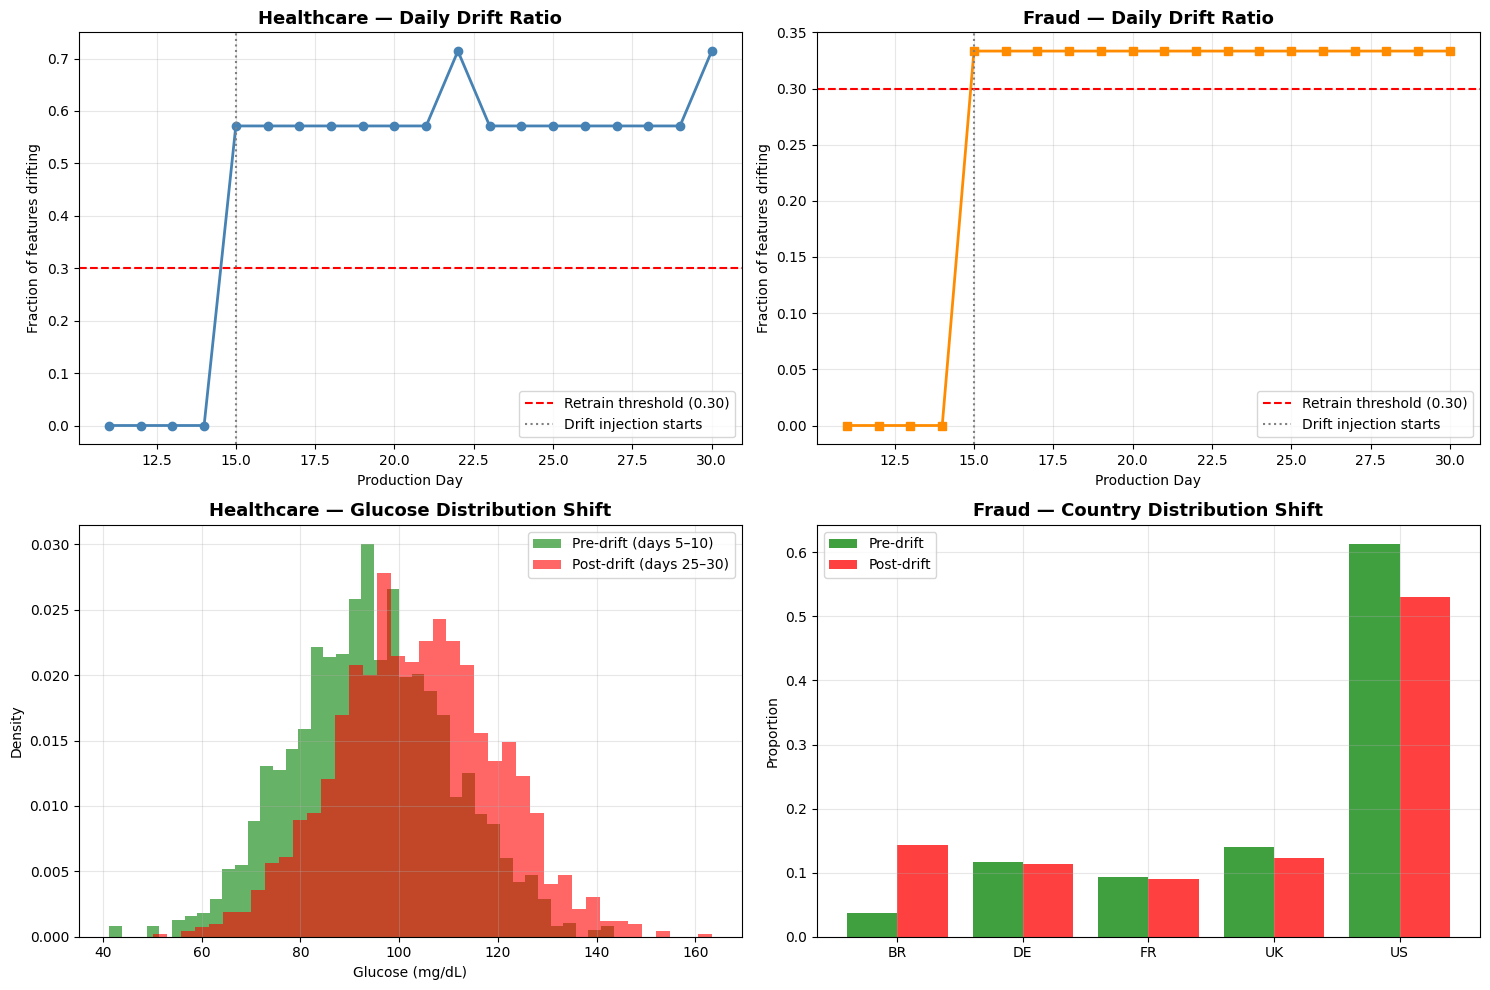

In [7]:
# ============================================================
# CELL 7: Visualizations — drift ratio over time + distributions
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- Healthcare: drift ratio over time ---
hc_days   = [int(h["date"].split("-")[1]) for h in hc_monitor.history]
hc_ratios = [h["drift_ratio"] for h in hc_monitor.history]
axes[0, 0].plot(hc_days, hc_ratios, marker="o", color="steelblue", linewidth=2)
axes[0, 0].axhline(0.3, color="red", linestyle="--", label="Retrain threshold (0.30)")
axes[0, 0].axvline(15, color="gray", linestyle=":", label="Drift injection starts")
axes[0, 0].set_title("Healthcare — Daily Drift Ratio", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Production Day")
axes[0, 0].set_ylabel("Fraction of features drifting")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- Fraud: drift ratio over time ---
fr_days   = [int(h["date"].split("-")[1]) for h in fraud_monitor.history]
fr_ratios = [h["drift_ratio"] for h in fraud_monitor.history]
axes[0, 1].plot(fr_days, fr_ratios, marker="s", color="darkorange", linewidth=2)
axes[0, 1].axhline(0.3, color="red", linestyle="--", label="Retrain threshold (0.30)")
axes[0, 1].axvline(15, color="gray", linestyle=":", label="Drift injection starts")
axes[0, 1].set_title("Fraud — Daily Drift Ratio", fontsize=13, fontweight="bold")
axes[0, 1].set_xlabel("Production Day")
axes[0, 1].set_ylabel("Fraction of features drifting")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- Healthcare: glucose distribution (drifted feature) ---
hc_pre  = healthcare_df[(healthcare_df["day"] >= 5) & (healthcare_df["day"] <= 10)]["glucose_mgdl"]
hc_post = healthcare_df[healthcare_df["day"] >= 25]["glucose_mgdl"]
axes[1, 0].hist(hc_pre,  bins=40, alpha=0.6, label="Pre-drift (days 5–10)",  color="green", density=True)
axes[1, 0].hist(hc_post, bins=40, alpha=0.6, label="Post-drift (days 25–30)", color="red",   density=True)
axes[1, 0].set_title("Healthcare — Glucose Distribution Shift", fontsize=13, fontweight="bold")
axes[1, 0].set_xlabel("Glucose (mg/dL)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# --- Fraud: country distribution (drifted categorical) ---
fr_pre  = fraud_df[fraud_df["day"] <= 10]["country"].value_counts(normalize=True).sort_index()
fr_post = fraud_df[fraud_df["day"] >= 25]["country"].value_counts(normalize=True).sort_index()
all_c = sorted(set(fr_pre.index) | set(fr_post.index))
x = np.arange(len(all_c))
axes[1, 1].bar(x - 0.2, [fr_pre.get(c, 0)  for c in all_c], width=0.4,
               label="Pre-drift",  color="green", alpha=0.75)
axes[1, 1].bar(x + 0.2, [fr_post.get(c, 0) for c in all_c], width=0.4,
               label="Post-drift", color="red",   alpha=0.75)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(all_c)
axes[1, 1].set_title("Fraud — Country Distribution Shift", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 8: Executive summary
# ============================================================
print("=" * 78)
print("📊  EXECUTIVE SUMMARY")
print("=" * 78)

hc_final = hc_monitor.decision(recent_days=3, drift_ratio_threshold=0.3)
fr_final = fraud_monitor.decision(recent_days=3, drift_ratio_threshold=0.3)

hc_last3 = np.mean([h["drift_ratio"] for h in hc_monitor.history[-3:]])
fr_last3 = np.mean([h["drift_ratio"] for h in fraud_monitor.history[-3:]])

print(f"\n🏥  Healthcare Lab Model:")
print(f"    Final decision:              {hc_final}")
print(f"    Avg drift ratio (last 3d):   {hc_last3:.2f}")
print(f"    → Action: Notify lab director, review assay lot calibration,")
print(f"              schedule retraining with fresh patient data.")

print(f"\n🏦  Fraud Detection Model:")
print(f"    Final decision:              {fr_final}")
print(f"    Avg drift ratio (last 3d):   {fr_last3:.2f}")
print(f"    → Action: Alert fraud ops team, investigate new attack pattern,")
print(f"              retrain with recent transactions.")

print("\n" + "=" * 78)
print("✅  Complete drift monitoring pipeline executed successfully.")
print("=" * 78)

📊  EXECUTIVE SUMMARY

🏥  Healthcare Lab Model:
    Final decision:              RETRAIN_RECOMMENDED
    Avg drift ratio (last 3d):   0.62
    → Action: Notify lab director, review assay lot calibration,
              schedule retraining with fresh patient data.

🏦  Fraud Detection Model:
    Final decision:              RETRAIN_RECOMMENDED
    Avg drift ratio (last 3d):   0.33
    → Action: Alert fraud ops team, investigate new attack pattern,
              retrain with recent transactions.

✅  Complete drift monitoring pipeline executed successfully.
